<a href="https://colab.research.google.com/github/RonakkudalAI/Practical-Machine-Learning/blob/main/SVM_(Day11).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc

In [4]:
dataset = pd.read_csv("/content/SNP (1).csv")
dataset

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [5]:
dataset.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [7]:
dataset.isnull().sum()

,0
Age,0
EstimatedSalary,0
Purchased,0


In [9]:
dataset.duplicated().sum()

np.int64(33)

In [10]:
dataset.drop_duplicates(inplace=True)

In [11]:
dataset.duplicated().sum()

np.int64(0)

In [12]:
dataset['Purchased'].value_counts()

,count
Purchased,
0,229
1,138


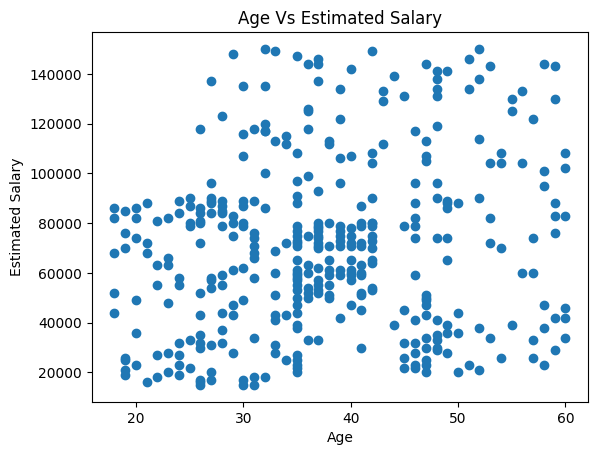

In [13]:
plt.scatter(dataset['Age'],dataset['EstimatedSalary'])
plt.title("Age Vs Estimated Salary")
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.show()

<Axes: >

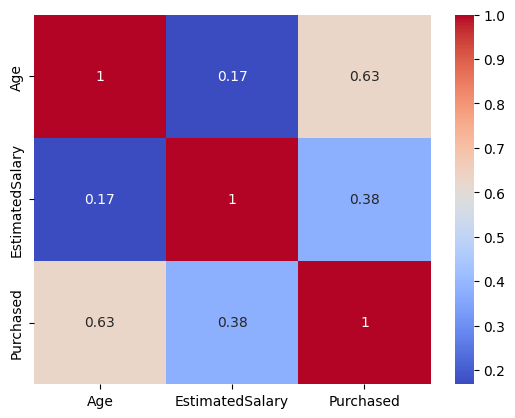

In [15]:
sns.heatmap(dataset.corr(), annot= True, cmap='coolwarm')

<Axes: xlabel='Age', ylabel='Count'>

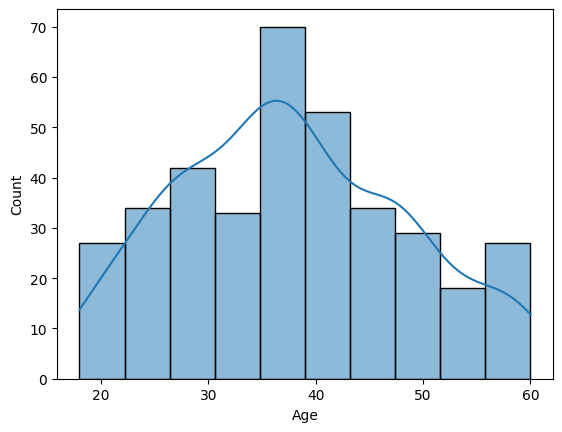

In [19]:
sns.histplot(data=dataset, x='Age', kde=True)

/tmp/ipykernel_1643/2649938937.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['Age'])


<Axes: xlabel='Age', ylabel='Density'>

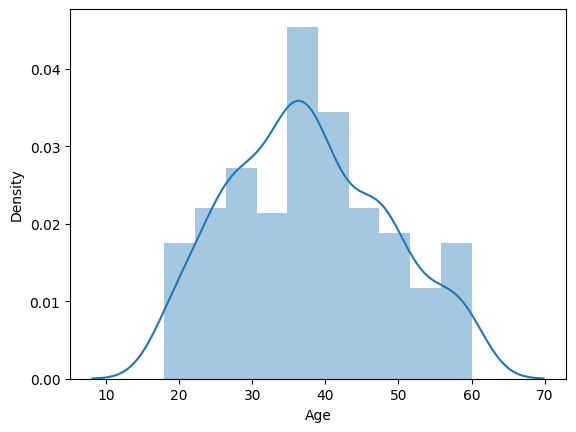

In [21]:
sns.distplot(dataset['Age'])

In [23]:
X = dataset[['Age','EstimatedSalary']].values
y = dataset['Purchased'].values

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.8,random_state=42)

In [26]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_Scaled = sc.fit_transform(X_train)
X_test_Scaled = sc.fit_transform(X_test)


In [28]:
from sklearn.svm import SVC

model = SVC(kernel='linear', random_state=42)

model.fit(X_train_Scaled, y_train)

SVC(kernel='linear', random_state=42)

In [29]:
y_pred = model.predict(X_test_Scaled)

In [31]:
print("Accuracy",accuracy_score(y_test,y_pred))
print("Confusion Matrix",confusion_matrix(y_test,y_pred))


Accuracy 0.8243243243243243
Confusion Matrix [[42  4]
 [ 9 19]]


In [33]:
def plot_decision_boundary(X_set, y_set, classifier, title):
    import numpy as np
    import matplotlib.pyplot as plt

    X1, X2 = np.meshgrid(
        np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
        np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
    )

    plt.figure(figsize=(8,6))

    # Decision boundary
    plt.contourf(
        X1, X2,
        model.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
        alpha=0.3
    )

    # Plot points
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(
            X_set[y_set == j, 0],
            X_set[y_set == j, 1],
            label=j
        )

    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.show()

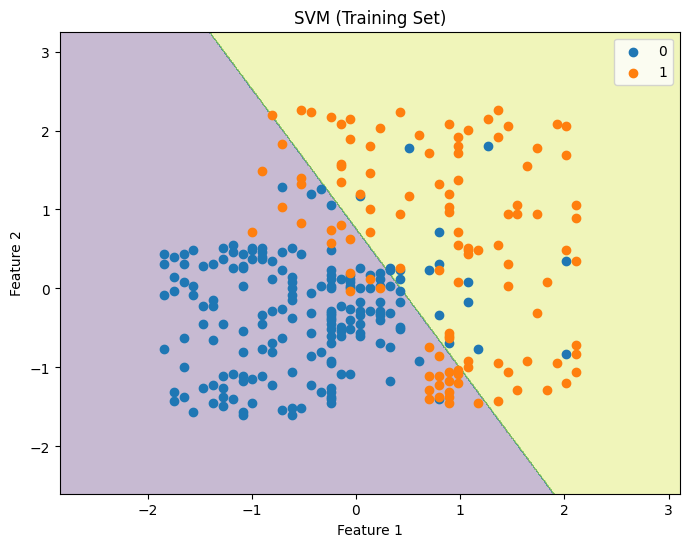

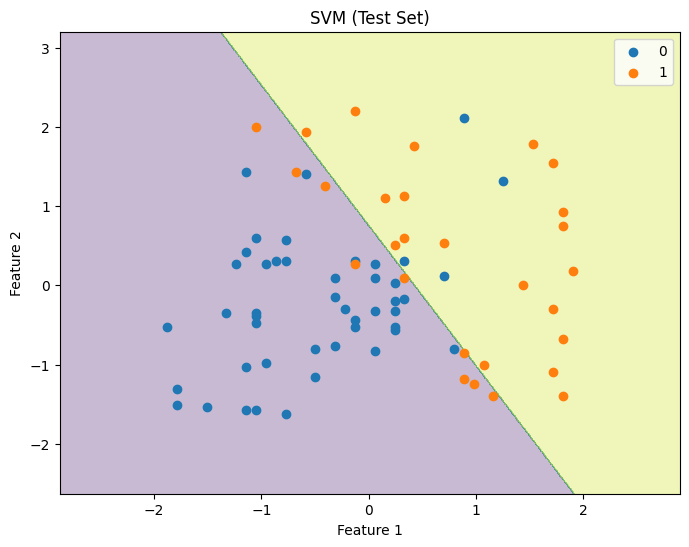

In [36]:
# Training set
plot_decision_boundary(X_train_Scaled, y_train, model, "SVM (Training Set)")

# Test set
plot_decision_boundary(X_test_Scaled, y_test, model, "SVM (Test Set)")

EX - Soft Margin

In [37]:
dataset['AgeSalary'] = dataset['Age']*dataset['EstimatedSalary']

In [45]:
X1 = dataset[['Age','EstimatedSalary','AgeSalary']]
y1= dataset['Purchased']

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split
X_train, X_test, y_train, y_test = train_test_split(X1, y1, train_size=0.8, random_state=42)

# Scaling
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [56]:
model1 = SVC(kernel = 'rbf',gamma='scale',C=1.0,random_state=42)
model1.fit(X_train_Scaled, y_train)

SVC(random_state=42)

In [66]:
y_pred1 = model.predict(X_test_scaled)

In [67]:
print("Accuracy",accuracy_score(y_test,y_pred1))
print("Confusion Matrix",confusion_matrix(y_test,y_pred1))


Accuracy 0.8783783783783784
Confusion Matrix [[41  5]
 [ 4 24]]


In [72]:
def plot_decision_boundary(X_set, y_set,model, title):
    X1, X2 = np.meshgrid(
        np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
        np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
    )

    plt.figure()
    plt.contourf(
        X1, X2,
        model1.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
        alpha=0.3
    )

    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(
            X_set[y_set == j, 0],
            X_set[y_set == j, 1],
            label=j
        )
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.show()

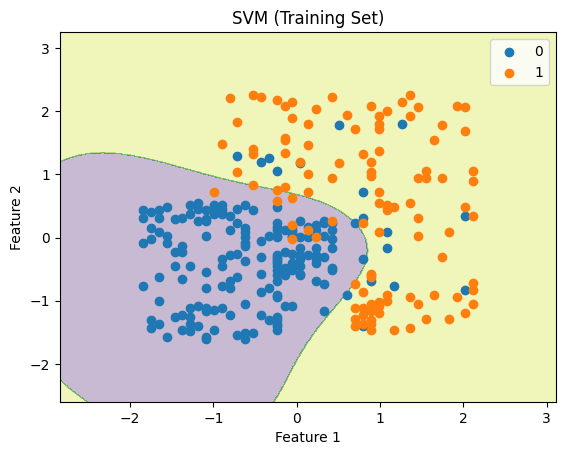

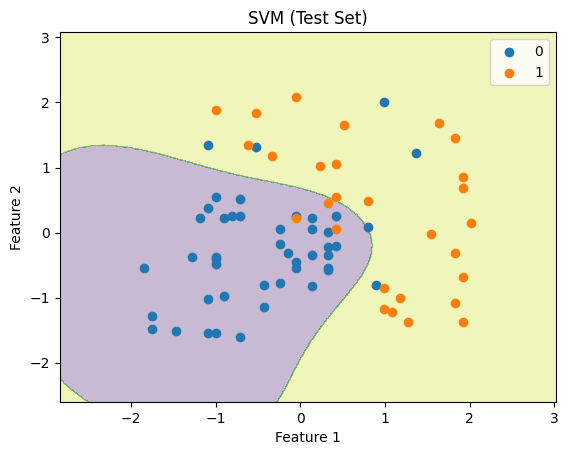

In [73]:
# Training set
plot_decision_boundary(X_train_scaled, y_train, model1, "SVM (Training Set)")

# Test set
plot_decision_boundary(X_test_scaled, y_test, model1, "SVM (Test Set)")

HyperParameter Tunning :Grid Search

In [96]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C' : [0.1,1,10,100,1000,5000,10000],
    'gamma': [1,0.1,0.01,0.001],
    'kernel':['rbf']
}

In [97]:
grid = GridSearchCV(estimator=SVC(),param_grid =param_grid, scoring='accuracy',cv=10,n_jobs=-1)


In [98]:
grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=10, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100, 1000, 5000, 10000],
                         'gamma': [1, 0.1, 0.01, 0.001], 'kernel': ['rbf']},
             scoring='accuracy')

In [99]:
grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=10, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100, 1000, 5000, 10000],
                         'gamma': [1, 0.1, 0.01, 0.001], 'kernel': ['rbf']},
             scoring='accuracy')

In [100]:
grid.best_score_

np.float64(0.9141379310344828)

In [101]:
grid.best_params_

{'C': 10, 'gamma': 1, 'kernel': 'rbf'}

In [102]:
grid.best_index_

np.int64(8)

In [103]:
grid.best_estimator_

SVC(C=10, gamma=1)